# Rain shifts

## Imports and files

In [1]:
import os
import pickle
import re
import itertools

# Date and time related imports
from datetime import datetime, timedelta

# Scientific libraries
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.interpolate import griddata

# Geospatial libraries
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Polygon, Point

# Plotting libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D

# SWMM related imports
from swmm_api.input_file import read_inp_file, SwmmInput, section_labels as sections
from swmm_api import read_out_file, read_rpt_file, swmm5_run, SwmmReport

## Functions

In [2]:
def load_sim_to_df(sim_output_path):
    """ Takes SWMM FILE with outflow data and makes pd Dataframe
    sim_output_path: str, file name that have the swmm outflow data
    return: sim_df
    """
    sim_df = read_out_file(sim_output_path).to_frame()['system'][''][['outflow', 'rainfall']]  # area weighted over all subcatchments 
    sim_df.rename(columns={'outflow':'SWMM outflow [CMS]', 'rainfall':'rainfall [mm/hr]'}, inplace=True, errors='raise')
    sim_df.index = pd.to_datetime(sim_df.index)
    return sim_df


def simulation_stat(storm_df):
    """
    Format statistical data from storm_df DataFrame.
    
    Calculates various statistical parameters based on the storm data in the storm_df DataFrame.
    
    Args:
        storm_df (pandas.DataFrame): DataFrame containing storm data from SWMM and OBS.
        
    Returns:
        Tuple containing the following:
        
        - swmm_total_outflow (float): Total outflow volume in cubic meters calculated from SWMM data.
        - swmm_max_outflow (float): Outflow peak in CMS (Cubic Meters per Second) from SWMM data.
        - swmm_max_outflow_time (datetime): Time of the outflow peak from SWMM data.
        - max_10min_intensity (float): Maximum 10-minute rainfall intensity in mm/hr for the entire storm.
        - max_20min_intensity (float): Maximum 20-minute average rainfall intensity in mm/hr for the entire storm.
        - max_30min_intensity (float): Maximum 30-minute average rainfall intensity in mm/hr for the entire storm.
        - max_60min_intensity (float): Maximum 60-minute average rainfall intensity in mm/hr for the entire storm.
        - max_120min_intensity (float): Maximum 120-minute average rainfall intensity in mm/hr for the entire storm.
        - max_240min_intensity (float): Maximum 240-minute average rainfall intensity in mm/hr for the entire storm.
        - max_360min_intensity (float): Maximum 360-minute average rainfall intensity in mm/hr for the entire storm.
        - max_720min_intensity (float): Maximum 720-minute average rainfall intensity in mm/hr for the entire storm.
        - max_1440min_intensity (float): Maximum 1440-minute average rainfall intensity in mm/hr for the entire storm.
        - total_rain (float): Total rainfall in mm for the entire storm.
        - max_10min_intensity_before_peak (float): Maximum 10-minute rainfall intensity in mm/hr before swmm_max_outflow_time.
        - max_20min_intensity_before_peak (float): Maximum 20-minute average rainfall intensity in mm/hr before swmm_max_outflow_time.
        - max_30min_intensity_before_peak (float): Maximum 30-minute average rainfall intensity in mm/hr before swmm_max_outflow_time.
        - max_60min_intensity_before_peak (float): Maximum 60-minute average rainfall intensity in mm/hr before swmm_max_outflow_time.
        - max_120min_intensity_before_peak (float): Maximum 120-minute average rainfall intensity in mm/hr before swmm_max_outflow_time.
        - max_240min_intensity_before_peak (float): Maximum 240-minute average rainfall intensity in mm/hr before swmm_max_outflow_time.
        - max_360min_intensity_before_peak (float): Maximum 360-minute average rainfall intensity in mm/hr before swmm_max_outflow_time.
        - max_720min_intensity_before_peak (float): Maximum 720-minute average rainfall intensity in mm/hr before swmm_max_outflow_time.
        - max_1440min_intensity_before_peak (float): Maximum 1440-minute average rainfall intensity in mm/hr before swmm_max_outflow_time.
        - total_rain_before_peak (float): Total rainfall in mm before swmm_max_outflow_time.
    """
    
    # Total outflow volume [cubic meter]
    swmm_total_outflow = sum(storm_df['SWMM outflow [CMS]']) * 60 * 10

    # Outflow peak [CMS] and time
    swmm_max_outflow = storm_df['SWMM outflow [CMS]'].max()
    swmm_max_outflow_time = storm_df[storm_df['SWMM outflow [CMS]'] == swmm_max_outflow].index[0]

    # Calculate rainfall intensities and total rain for the entire storm
    rainfall_10min = storm_df['rainfall [mm/hr]'].resample('10T').sum()
    max_10min_intensity = rainfall_10min.max()
    
    rainfall_20min = rainfall_10min.rolling(window=2).mean()
    rainfall_30min = rainfall_10min.rolling(window=3).mean()
    rainfall_60min = rainfall_10min.rolling(window=6).mean()
    rainfall_120min = rainfall_10min.rolling(window=12).mean()
    rainfall_240min = rainfall_10min.rolling(window=24).mean()
    rainfall_360min = rainfall_10min.rolling(window=36).mean()
    rainfall_720min = rainfall_10min.rolling(window=72).mean()
    rainfall_1440min = rainfall_10min.rolling(window=144).mean()
    
    max_20min_intensity = rainfall_20min.max()
    max_30min_intensity = rainfall_30min.max()
    max_60min_intensity = rainfall_60min.max()
    max_120min_intensity = rainfall_120min.max()
    max_240min_intensity = rainfall_240min.max()
    max_360min_intensity = rainfall_360min.max()
    max_720min_intensity = rainfall_720min.max()
    max_1440min_intensity = rainfall_1440min.max()
    
    total_rain = storm_df['rainfall [mm/hr]'].sum() / 6  # convert from mm/hr to mm in 10 minutes interval

    # Filter data before the peak outflow time
    df_before_peak = storm_df[storm_df.index <= swmm_max_outflow_time]
    
    # Calculate rainfall intensities and total rain before the peak outflow time
    rainfall_10min_before_peak = df_before_peak['rainfall [mm/hr]'].resample('10T').sum()
    max_10min_intensity_before_peak = rainfall_10min_before_peak.max()
    
    rainfall_20min_before_peak = rainfall_10min_before_peak.rolling(window=2).mean()
    rainfall_30min_before_peak = rainfall_10min_before_peak.rolling(window=3).mean()
    rainfall_60min_before_peak = rainfall_10min_before_peak.rolling(window=6).mean()
    rainfall_120min_before_peak = rainfall_10min_before_peak.rolling(window=12).mean()
    rainfall_240min_before_peak = rainfall_10min_before_peak.rolling(window=24).mean()
    rainfall_360min_before_peak = rainfall_10min_before_peak.rolling(window=36).mean()
    rainfall_720min_before_peak = rainfall_10min_before_peak.rolling(window=72).mean()
    rainfall_1440min_before_peak = rainfall_10min_before_peak.rolling(window=144).mean()
    
    max_20min_intensity_before_peak = rainfall_20min_before_peak.max()
    max_30min_intensity_before_peak = rainfall_30min_before_peak.max()
    max_60min_intensity_before_peak = rainfall_60min_before_peak.max()
    max_120min_intensity_before_peak = rainfall_120min_before_peak.max()
    max_240min_intensity_before_peak = rainfall_240min_before_peak.max()
    max_360min_intensity_before_peak = rainfall_360min_before_peak.max()
    max_720min_intensity_before_peak = rainfall_720min_before_peak.max()
    max_1440min_intensity_before_peak = rainfall_1440min_before_peak.max()
    
    total_rain_before_peak = df_before_peak['rainfall [mm/hr]'].sum() / 6  # convert from mm/hr to mm in 10 minutes interval

    return (swmm_total_outflow, swmm_max_outflow, swmm_max_outflow_time,
            max_10min_intensity, max_20min_intensity, max_30min_intensity, max_60min_intensity,
            max_120min_intensity, max_240min_intensity, max_360min_intensity,
            max_720min_intensity, max_1440min_intensity, total_rain,
            max_10min_intensity_before_peak, max_20min_intensity_before_peak, max_30min_intensity_before_peak, 
            max_60min_intensity_before_peak, max_120min_intensity_before_peak, max_240min_intensity_before_peak,
            max_360min_intensity_before_peak, max_720min_intensity_before_peak, max_1440min_intensity_before_peak,
            total_rain_before_peak)


In [3]:
def read_rain_shift_txt_file(rain_shift_directory_path, x_shift, y_shift):
    # List all files in the directory
    files_in_directory = os.listdir(rain_shift_directory_path)

    # Filter files with the desired format
    matching_files = [file for file in files_in_directory if "rain_shift_" in file]

    if not matching_files:
        print("No matching files found.")
        return None, None, None

    # Find the file that matches the specified x_shift and y_shift
    x_shift_str = str(abs(x_shift))
    y_shift_str = str(abs(y_shift))
    matching_file = None
    for file in matching_files:
        x_match = re.search(r'x(plus|minus)_(\d+)', file)
        y_match = re.search(r'y(plus|minus)_(\d+)', file)
        
        if x_match and y_match:
            file_x_shift = int(x_match.group(2)) * (1 if x_match.group(1) == 'plus' else -1)
            file_y_shift = int(y_match.group(2)) * (1 if y_match.group(1) == 'plus' else -1)
            if file_x_shift == x_shift and file_y_shift == y_shift:
                matching_file = file
                break

    if not matching_file:
        print(f"No file found with x_shift: {x_shift} and y_shift: {y_shift}")
        return None, None, None

    # Construct the file path
    file_path = os.path.join(rain_shift_directory_path, matching_file)

    # Open and read the contents of the matched file
    with open(file_path, 'r') as file:
        rain_shift_txt = file.read()

    # Return x_shift, y_shift, and file_contents
    return rain_shift_txt

In [4]:
def parse_date_time(row):
    """
    Parse date and time from a formatted row.
    """
    columns = row.split()
    date_str = columns[1]
    time_str = columns[2]
    date = datetime.strptime(date_str, '%m/%d/%Y').date()
    time = datetime.strptime(time_str, '%H:%M:%S').time()
    return date, time

def update_TimeSeriesData(inp, timeseries_text):
    """
    Update the time series data in an input file used for simulation.
    
    Args:
    - inp (dict): Dictionary containing simulation input data.
    - timeseries_text (str): Text containing transformed time series data.
    
    Returns:
    - None
    """
    lines = timeseries_text.strip().split('\n')
    data_rows = [line for line in lines if not line.startswith(';;')]
    
    # Parse the first and last data rows for start and end times
    first_date, first_time = parse_date_time(data_rows[0])
    second_date, second_time = parse_date_time(data_rows[1])
    last_date, last_time = parse_date_time(data_rows[-1])
    
    first_datetime = datetime.combine(first_date, first_time)
    second_datetime = datetime.combine(second_date, second_time)
    
    # Calculate time interval between the first and second rows
    first_timedelta = timedelta(hours=first_time.hour, minutes=first_time.minute, seconds=first_time.second)
    second_timedelta = timedelta(hours=second_time.hour, minutes=second_time.minute, seconds=second_time.second)
    
    # Calculate the difference
    time_interval = str(second_timedelta - first_timedelta)
    
    # Calculate start and end times
    start_datetime = datetime.combine(first_date, first_time)
    if start_datetime.hour < 6:
        start_datetime -= timedelta(days=1)
    START_DATE = start_datetime.date()
    REPORT_START_DATE = START_DATE
    START_TIME = (start_datetime - timedelta(hours=6)).time()
    REPORT_START_TIME = START_TIME
    
    end_datetime = datetime.combine(last_date, last_time)
    if end_datetime.hour >= 18:
        end_datetime += timedelta(days=1)
    END_DATE = end_datetime.date()
    END_TIME = (end_datetime + timedelta(hours=6)).time()
    
    # Update the options section with calculated times
    inp['OPTIONS']['START_DATE'] = START_DATE
    inp['OPTIONS']['START_TIME'] = START_TIME
    inp['OPTIONS']['REPORT_START_DATE'] = REPORT_START_DATE
    inp['OPTIONS']['REPORT_START_TIME'] = REPORT_START_TIME
    inp['OPTIONS']['END_DATE'] = END_DATE
    inp['OPTIONS']['END_TIME'] = END_TIME
    
    # Update the time series section with new data
    inp['TIMESERIES'] = timeseries_text

    # Ensure that the number of time series matches the number of rain gauges
    if len(inp['TIMESERIES'].keys()) != len(inp['RAINGAGES'].keys()):
        raise ValueError('ERROR: The number of time series does not match the number of rain gauges.')

    # Edit the time series name and its corresponding rain gauge field
    for basin_timeserie in range(len(list(inp['TIMESERIES'].keys()))):
        basin_timeserie_name = inp['TIMESERIES'][list(inp['TIMESERIES'].keys())[basin_timeserie]]['name']
        inp['RAINGAGES'][list(inp['RAINGAGES'].keys())[basin_timeserie]]['timeseries'] = basin_timeserie_name
        inp['RAINGAGES'][list(inp['RAINGAGES'].keys())[basin_timeserie]]['interval'] = time_interval
        inp['RAINGAGES'][list(inp['RAINGAGES'].keys())[basin_timeserie]]['form'] = "INTENSITY"


In [5]:
def update_imperviousness_with_factor(subcatchment_dict, factor, impervious_initial_values):
    """
    Update the imperviousness values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which imperviousness values need to be powered.

    Returns:
        dict: The updated dictionary with imperviousness values powered by the factor.
    """


    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
        initial_imperviousness = impervious_initial_values[index]
        subcatchment.imperviousness = initial_imperviousness
        powered_imperviousness = subcatchment.imperviousness * factor
        # Update the imperviousness value for the current subcatchment with the powered imperviousness value
        subcatchment.imperviousness = powered_imperviousness


    # Return the updated dictionary
    return subcatchment_dict

# Run and plot shifts simulations hydrographs

## Ensemble events hydrographs

In [8]:
def extract_shifts(column_name):
    """
    Extract x_shift and y_shift from a column name formatted as 'ensemble_x{x_shift}_y{y_shift}_runoff' or 'ensemble_x{x_shift}_y{y_shift}_rainfall'.
    
    Args:
        column_name (str): The column name from which to extract shifts.
        
    Returns:
        tuple: A tuple containing x_shift and y_shift as integers.
    """
    # Find the start and end positions for x_shift
    x_start = column_name.find('x') + 1
    x_end = column_name.find('_', x_start)
    
    # Find the start and end positions for y_shift
    y_start = column_name.find('y') + 1
    y_end = column_name.find('_', y_start)
    
    # Extract and convert the shift values to integers
    x_shift = int(column_name[x_start:x_end])
    y_shift = int(column_name[y_start:y_end])
    
    return x_shift, y_shift

In [9]:
def plot_ensemble_hydrograph(historical_event_results_df, future_event_results_df, event_num, historical_ensemble, future_ensemble, ensemble_member_percentile=0.75):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Identify the peak discharge for each ensemble member
    peak_historical_runoff = historical_ensemble.filter(like='runoff').max(axis=0)
    peak_future_runoff = future_ensemble.filter(like='runoff').max(axis=0)
    
    # Calculate the quantiles based on peak discharge values
    historical_quantile_value = peak_historical_runoff.quantile(ensemble_member_percentile)
    future_quantile_value = peak_future_runoff.quantile(ensemble_member_percentile)
    
    # Identify the ensemble member closest to the selected quantile
    selected_historical_member = peak_historical_runoff.sub(historical_quantile_value).abs().idxmin()
    selected_future_member = peak_future_runoff.sub(future_quantile_value).abs().idxmin()

    selected_historical_x_shift, selected_historical_y_shift = extract_shifts(selected_historical_member)
    selected_future_x_shift, selected_future_y_shift = extract_shifts(selected_future_member)
    
    selected_historical_event_results_df = historical_event_results_df[
    (historical_event_results_df[('x', '')] == selected_historical_x_shift) &
    (historical_event_results_df[('y', '')] == selected_historical_y_shift)
    ]
        
    selected_future_event_results_df = future_event_results_df[
    (future_event_results_df[('x', '')] == selected_future_x_shift) &
    (future_event_results_df[('y', '')] == selected_future_y_shift)
    ]
    
    # Extract values for the text box
    historical_total_rain = selected_historical_event_results_df[('historical', 'total_rain')].values[0]
    historical_max_intensity = selected_historical_event_results_df[('historical', 'max_30min_intensity')].values[0]
    future_total_rain = selected_future_event_results_df[('future', 'total_rain')].values[0]
    future_max_intensity = selected_future_event_results_df[('future', 'max_30min_intensity')].values[0]
    
    fig.suptitle(f"Event {event_num} Ensemble (Selected: {ensemble_member_percentile:.2f}th Percentile - Peak): {historical_ensemble.index.strftime('%d/%m/%Y')[0]}", fontsize=20)
    
    historical_color = sns.color_palette("Set2")[0]
    future_color = sns.color_palette("Set2")[1]
    
    # Plot the band for historical ensemble between 5th and 95th percentiles
    ax.fill_between(historical_ensemble.index, 
                    historical_ensemble.filter(like='runoff').quantile(0.05, axis=1), 
                    historical_ensemble.filter(like='runoff').quantile(0.95, axis=1), 
                    color=historical_color, alpha=0.3)

    # Plot the selected historical ensemble member
    sns.lineplot(ax=ax, data=historical_ensemble[selected_historical_member], color=historical_color, linewidth=1.5, label=f'Historical outflow {ensemble_member_percentile}th percentile')
    
    # Plot the band for future ensemble between 5th and 95th percentiles
    ax.fill_between(future_ensemble.index, 
                    future_ensemble.filter(like='runoff').quantile(0.05, axis=1), 
                    future_ensemble.filter(like='runoff').quantile(0.95, axis=1), 
                    color=future_color, alpha=0.3)

    # Plot the selected future ensemble member
    sns.lineplot(ax=ax, data=future_ensemble[selected_future_member], color=future_color, linewidth=1.5, label=f'Future outflow {ensemble_member_percentile}th percentile')

    ax2 = ax.twinx()
    
    # Plot rainfall band for historical ensemble between 5th and 95th percentiles
    ax2.fill_between(historical_ensemble.index, 
                     historical_ensemble.filter(like='rainfall').quantile(0.05, axis=1), 
                     historical_ensemble.filter(like='rainfall').quantile(0.95, axis=1), 
                     color='b', alpha=0.3)

    # Plot the selected historical rainfall ensemble member
    selected_historical_rainfall_member = selected_historical_member.replace('runoff', 'rainfall')
    sns.lineplot(ax=ax2, data=historical_ensemble[selected_historical_rainfall_member], color='b', linewidth=1.5, label=f'Historical rainfall {ensemble_member_percentile}th percentile')
    
    # Plot rainfall band for future ensemble between 5th and 95th percentiles
    ax2.fill_between(future_ensemble.index, 
                     future_ensemble.filter(like='rainfall').quantile(0.05, axis=1), 
                     future_ensemble.filter(like='rainfall').quantile(0.95, axis=1), 
                     color='purple', alpha=0.3)

    # Plot the selected future rainfall ensemble member
    selected_future_rainfall_member = selected_future_member.replace('runoff', 'rainfall')
    sns.lineplot(ax=ax2, data=future_ensemble[selected_future_rainfall_member], color='purple', linewidth=1.5, label=f'Future rainfall {ensemble_member_percentile}th percentile')

    ax2.set_ylim(ymin=100, ymax=0)
    ax.set_ylim(ymin=0, ymax=90)

    ax2.set_xlabel('Time', fontsize=18)
    ax2.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax.set_ylabel('Outflow ($m^{3}s^{-1}$)', fontsize=18)

    ax2.legend().remove()

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax.legend(handles, labels, loc='center right', fontsize=10)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax.tick_params(axis='y', labelsize=18)
    ax2.tick_params(axis='y', labelsize=18)
    ax.grid()
    
    # Add text box with values
    textstr = '\n'.join((
        f"Historical Total Rain: {historical_total_rain:.2f} mm",
        f"Historical Max 30min Intensity: {historical_max_intensity:.2f} mm/hr",
        f"Future Total Rain: {future_total_rain:.2f} mm",
        f"Future Max 30min Intensity: {future_max_intensity:.2f} mm/hr"
    ))
    
    # Define position and properties of the text box
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    ax.text(.65, 0.8, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', ha='left',  bbox=props)

    save_path = os.path.join("D:/Development/RESEARCH/Raanana/figures/climate_change_shifts/optimal_model/hydrograph/ensemble", f"hydrograph_event_{event_num}.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


In [10]:
def plot_ensemble_rainfall(historical_event_results_df, future_event_results_df, event_num, historical_ensemble, future_ensemble, ensemble_member_percentile=0.75):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Identify the peak rainfall for each ensemble member
    peak_historical_rainfall = historical_ensemble.filter(like='rainfall').max(axis=0)
    peak_future_rainfall = future_ensemble.filter(like='rainfall').max(axis=0)
    
    # Calculate the quantiles based on peak rainfall values
    historical_quantile_value = peak_historical_rainfall.quantile(ensemble_member_percentile)
    future_quantile_value = peak_future_rainfall.quantile(ensemble_member_percentile)
    
    # Identify the ensemble member closest to the selected quantile
    selected_historical_member = peak_historical_rainfall.sub(historical_quantile_value).abs().idxmin()
    selected_future_member = peak_future_rainfall.sub(future_quantile_value).abs().idxmin()
    
    historical_color = sns.color_palette("Set2")[0]
    future_color = sns.color_palette("Set2")[1]
    
#     # Plot the band for historical ensemble between 5th and 95th percentiles
#     ax.fill_between(historical_ensemble.index, 
#                     historical_ensemble.filter(like='rainfall').quantile(0.05, axis=1), 
#                     historical_ensemble.filter(like='rainfall').quantile(0.95, axis=1), 
#                     color=historical_color, alpha=0.3, label="Historical Rainfall (5th-95th Percentile)")
    
    # Plot the selected historical ensemble member
    sns.lineplot(ax=ax, data=historical_ensemble[selected_historical_member], color=historical_color, linewidth=1.5, label=f'Historical Rainfall {ensemble_member_percentile}th Percentile')

#     # Plot the band for future ensemble between 5th and 95th percentiles
#     ax.fill_between(future_ensemble.index, 
#                     future_ensemble.filter(like='rainfall').quantile(0.05, axis=1), 
#                     future_ensemble.filter(like='rainfall').quantile(0.95, axis=1), 
#                     color=future_color, alpha=0.3, label="Future Rainfall (5th-95th Percentile)")
    
    # Plot the selected future ensemble member
    sns.lineplot(ax=ax, data=future_ensemble[selected_future_member], color=future_color, linewidth=1.5, label=f'Future Rainfall {ensemble_member_percentile}th Percentile')

    # Extract values for the text box
    selected_historical_x_shift, selected_historical_y_shift = extract_shifts(selected_historical_member)
    selected_future_x_shift, selected_future_y_shift = extract_shifts(selected_future_member)
    
    selected_historical_event_results_df = historical_event_results_df[
        (historical_event_results_df[('x', '')] == selected_historical_x_shift) &
        (historical_event_results_df[('y', '')] == selected_historical_y_shift)
    ]
    selected_future_event_results_df = future_event_results_df[
        (future_event_results_df[('x', '')] == selected_future_x_shift) &
        (future_event_results_df[('y', '')] == selected_future_y_shift)
    ]
    
    historical_total_rain = selected_historical_event_results_df[('historical', 'total_rain')].values[0]
    future_total_rain = selected_future_event_results_df[('future', 'total_rain')].values[0]
    
    textstr = '\n'.join((
        f"Historical Total Rain: {historical_total_rain:.2f} mm",
        f"Future Total Rain: {future_total_rain:.2f} mm"
    ))
    
    # Define position and properties of the text box
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    ax.text(.65, 0.8, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', ha='left', bbox=props)
    
    # Set labels, legend, and title
    ax.set_xlabel('Time', fontsize=18)
    ax.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax.set_title(f"Rainfall Ensemble (Event {event_num})", fontsize=20)
    ax.legend(loc='upper right', fontsize=10)
    
    # Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax.tick_params(axis='y', labelsize=18)
    ax.grid()

    save_path = os.path.join("D:/Development/RESEARCH/Raanana/figures/climate_change_shifts/optimal_model/hydrograph/rainfall_ensemble", f"rainfall_event_{event_num}.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


Event number 1, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

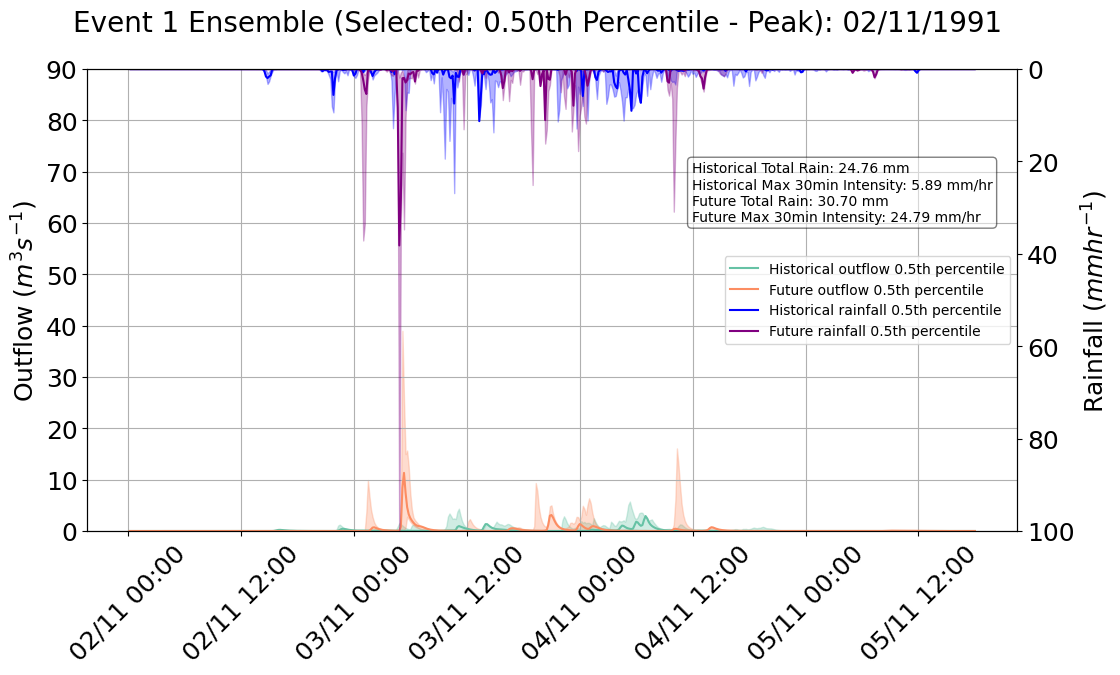

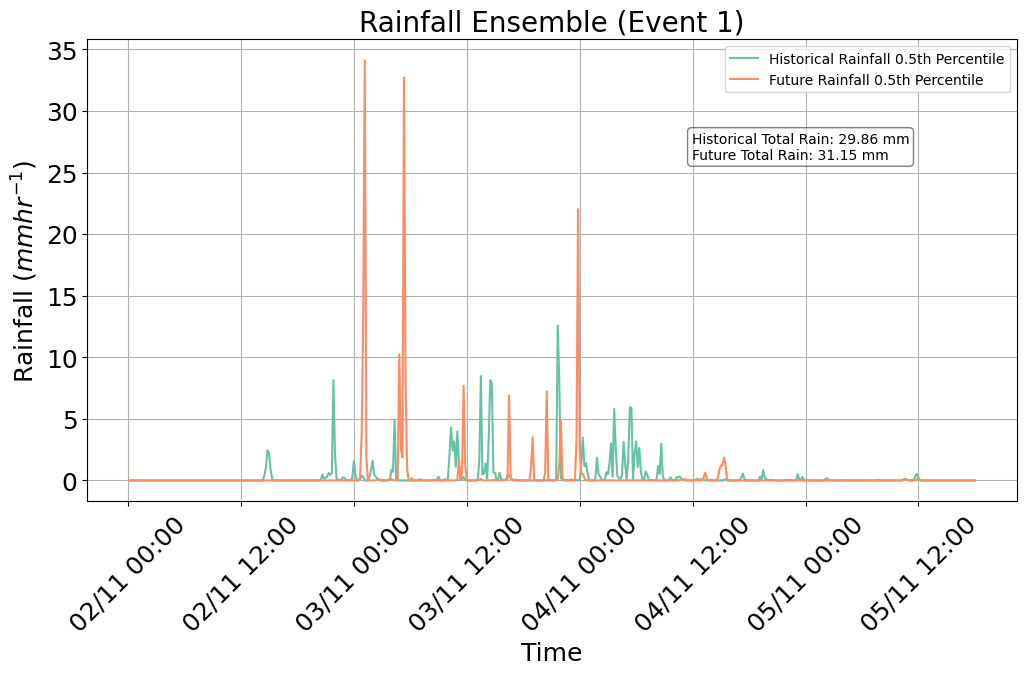

Event number 2, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

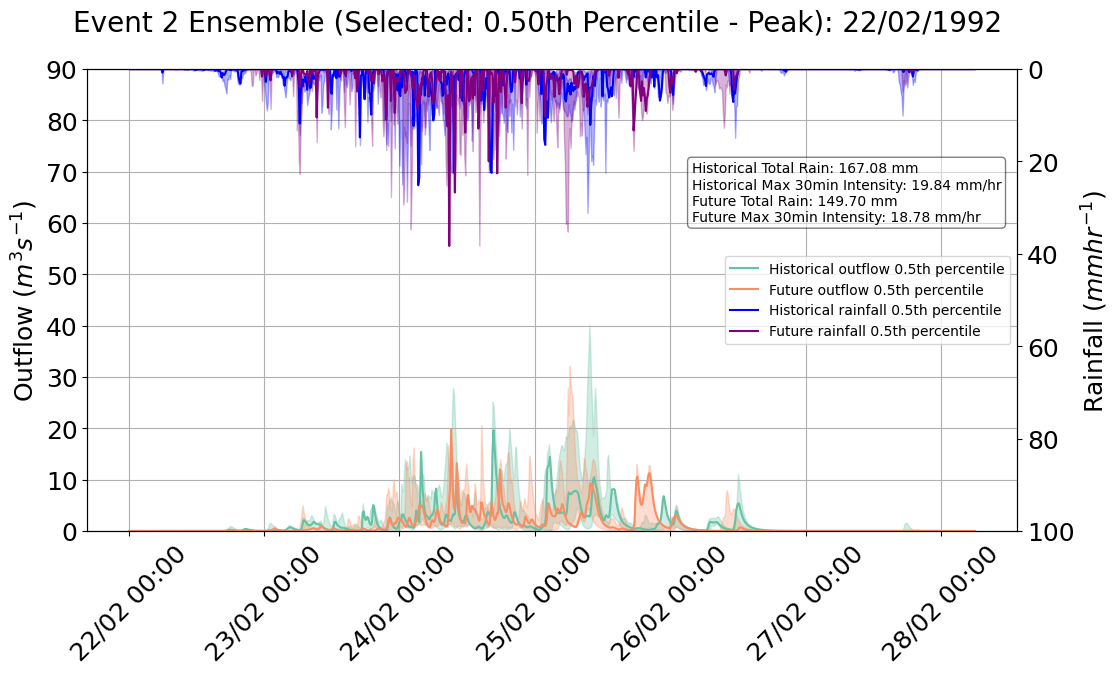

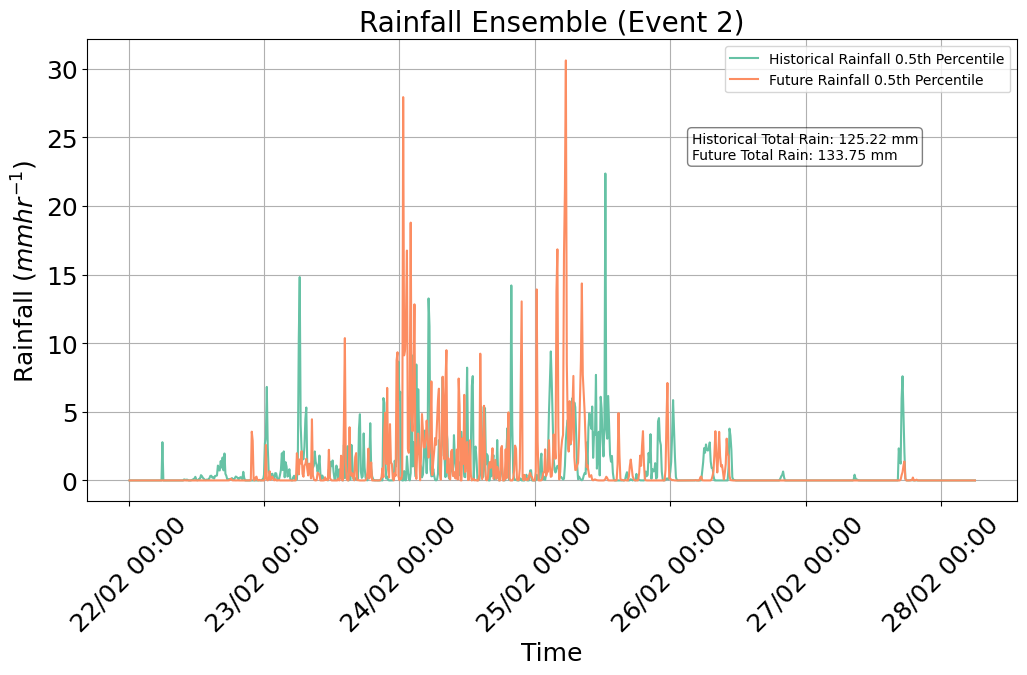

Event number 3, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

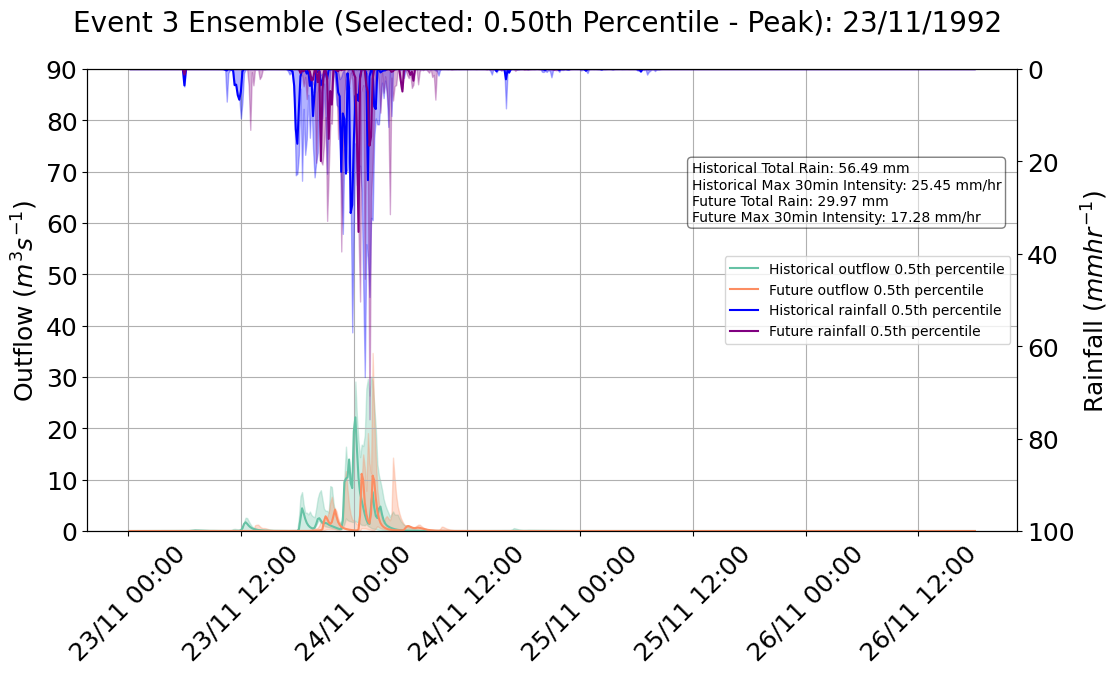

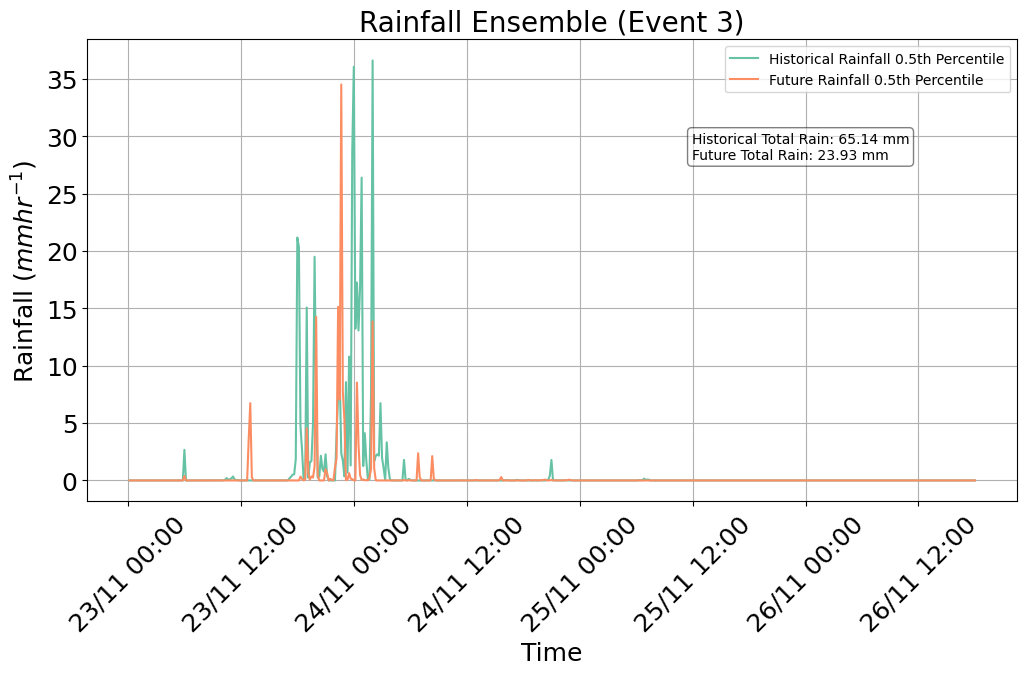

Event number 4, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

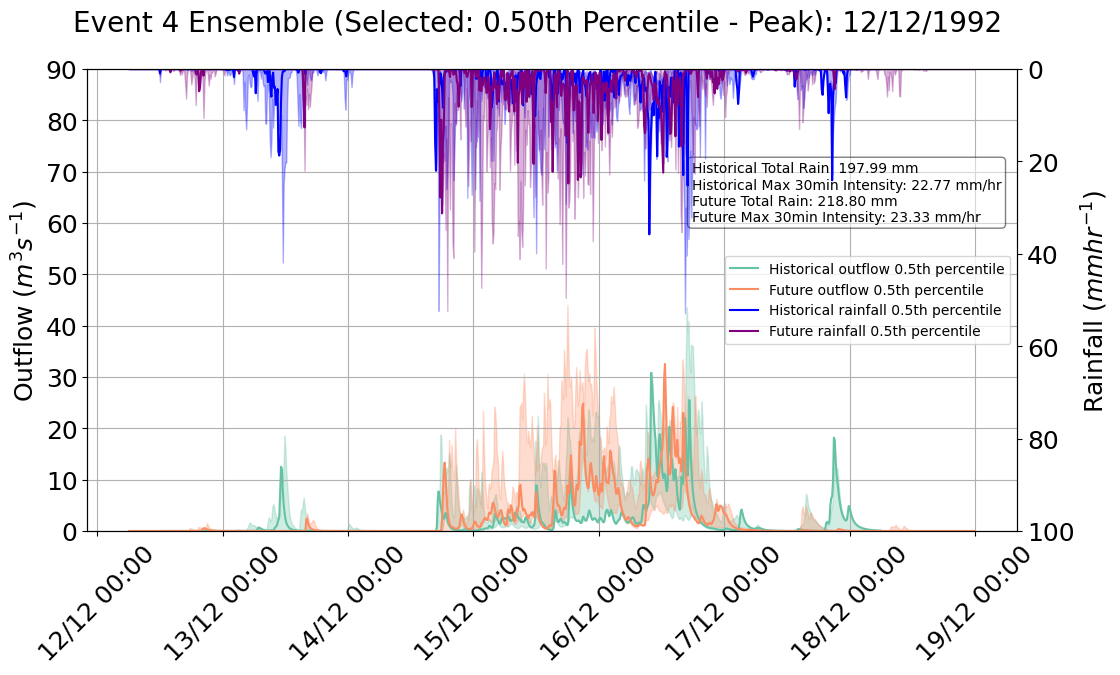

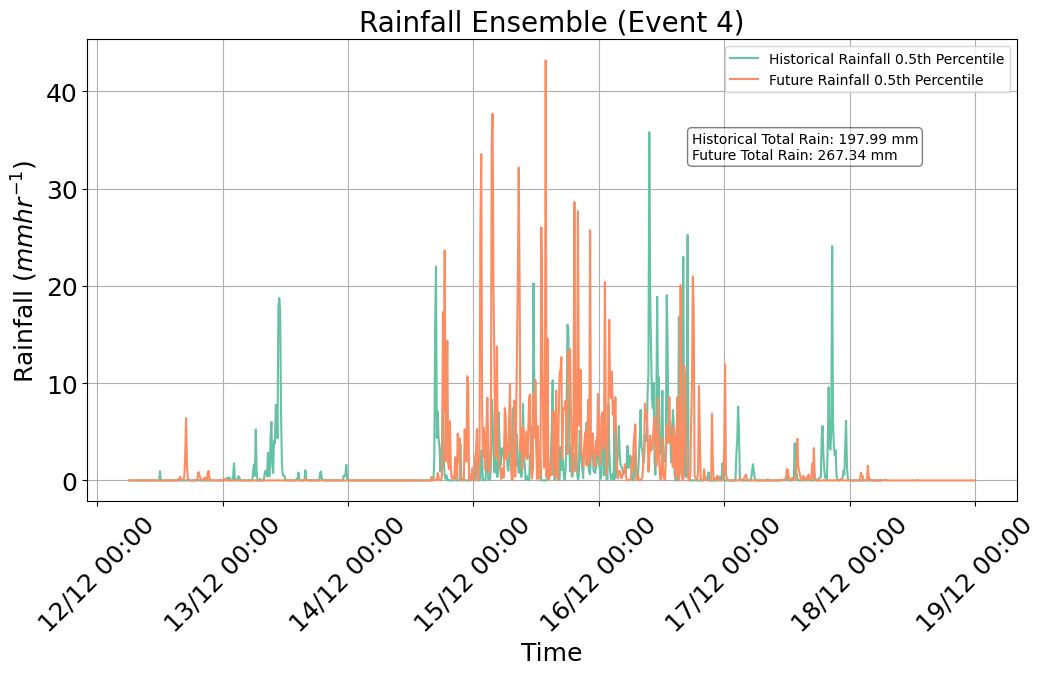

Event number 5, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

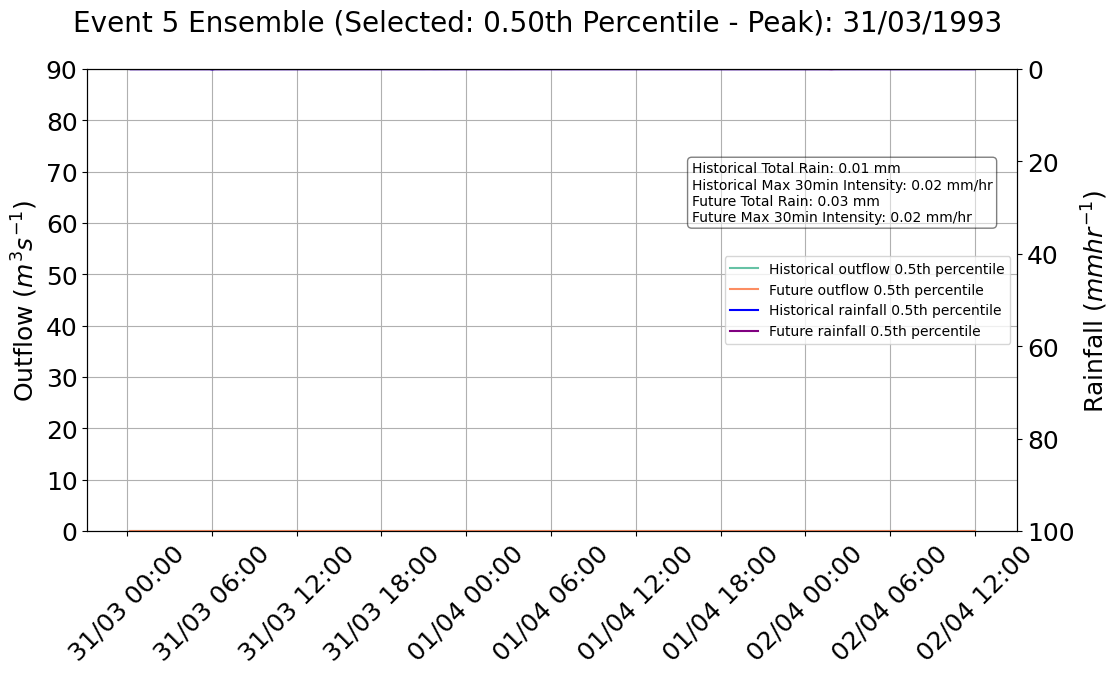

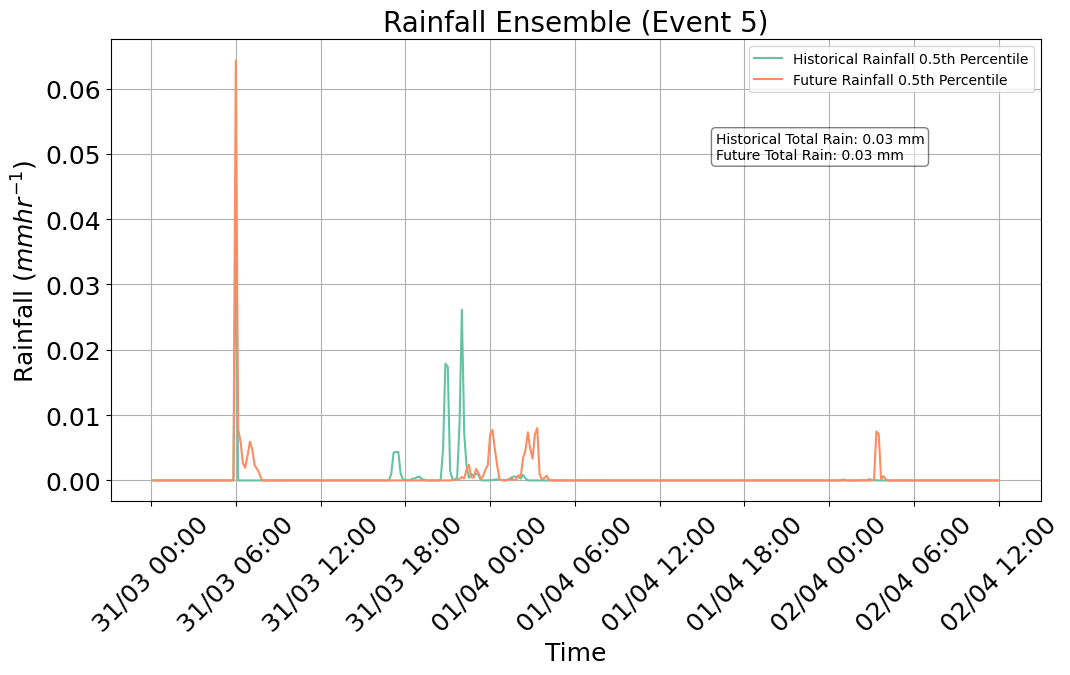

Event number 6, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

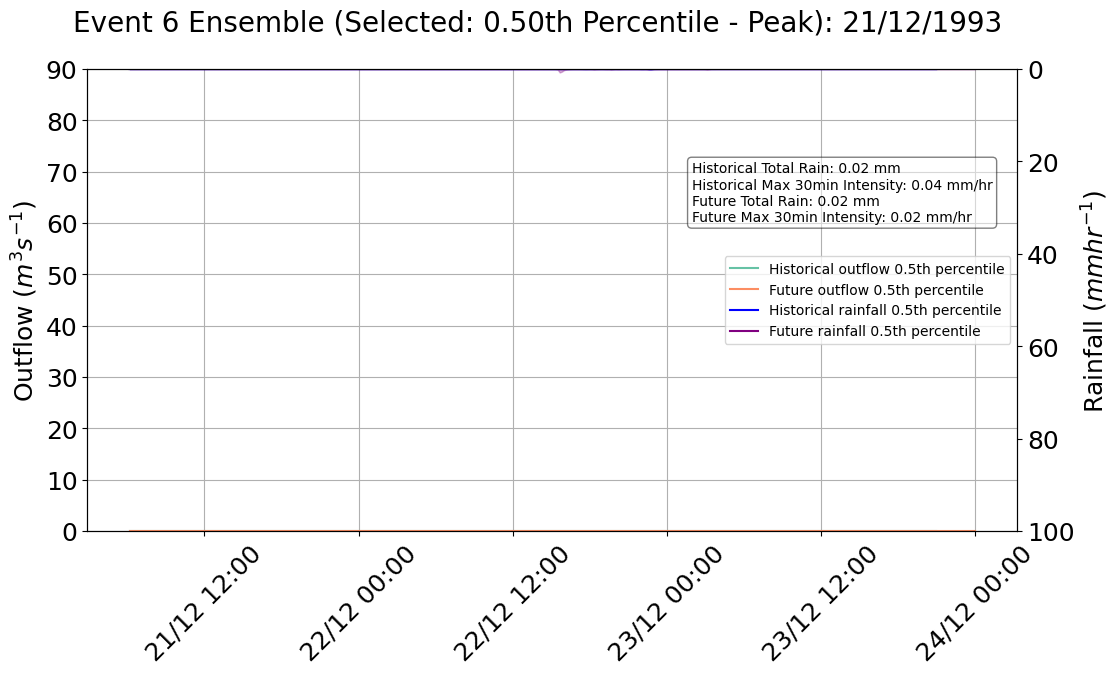

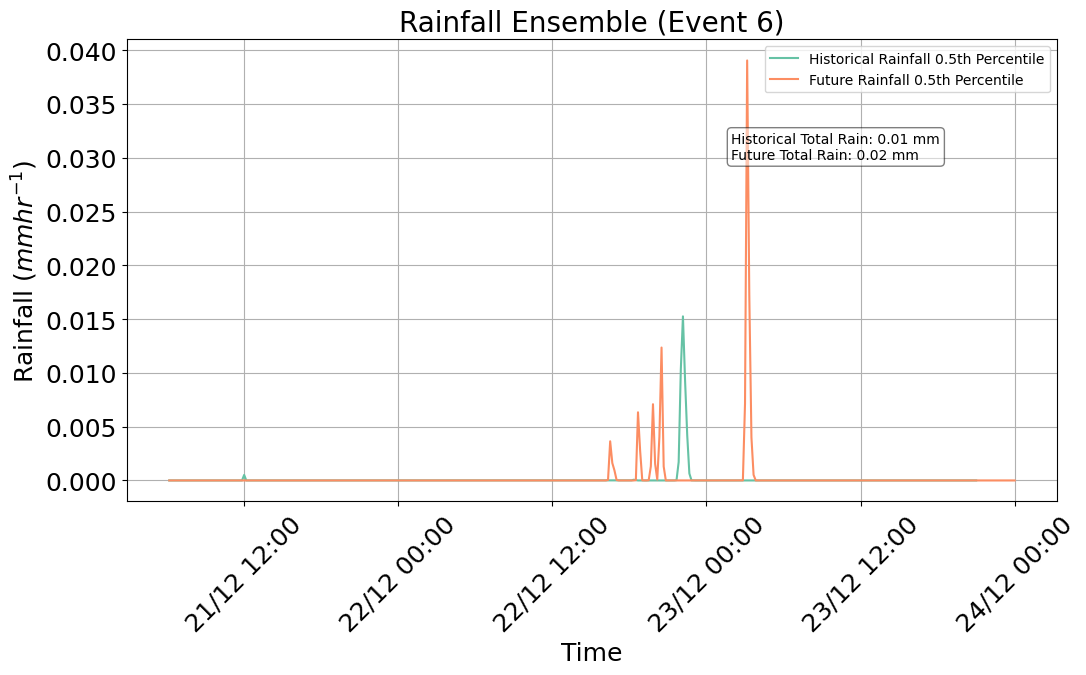

Event number 7, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

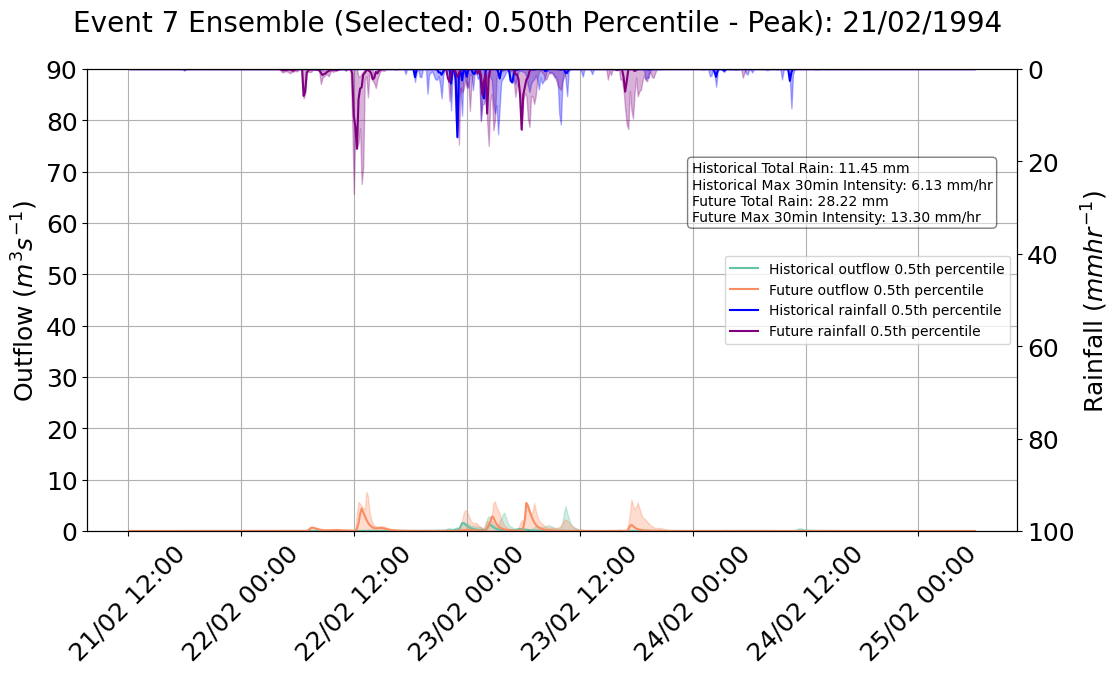

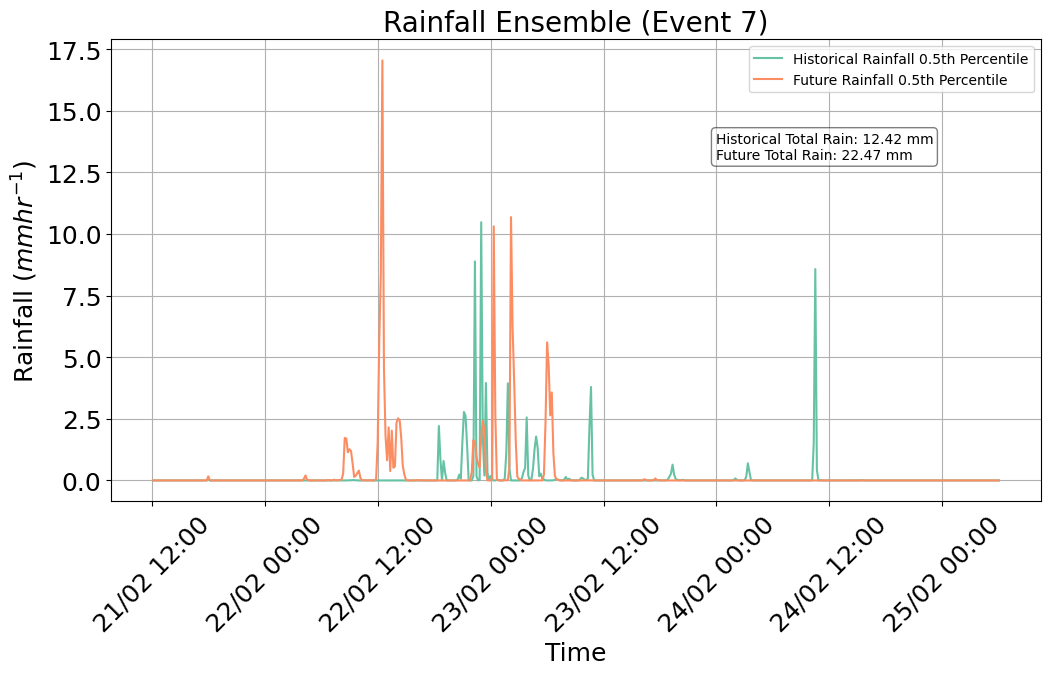

Event number 8, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

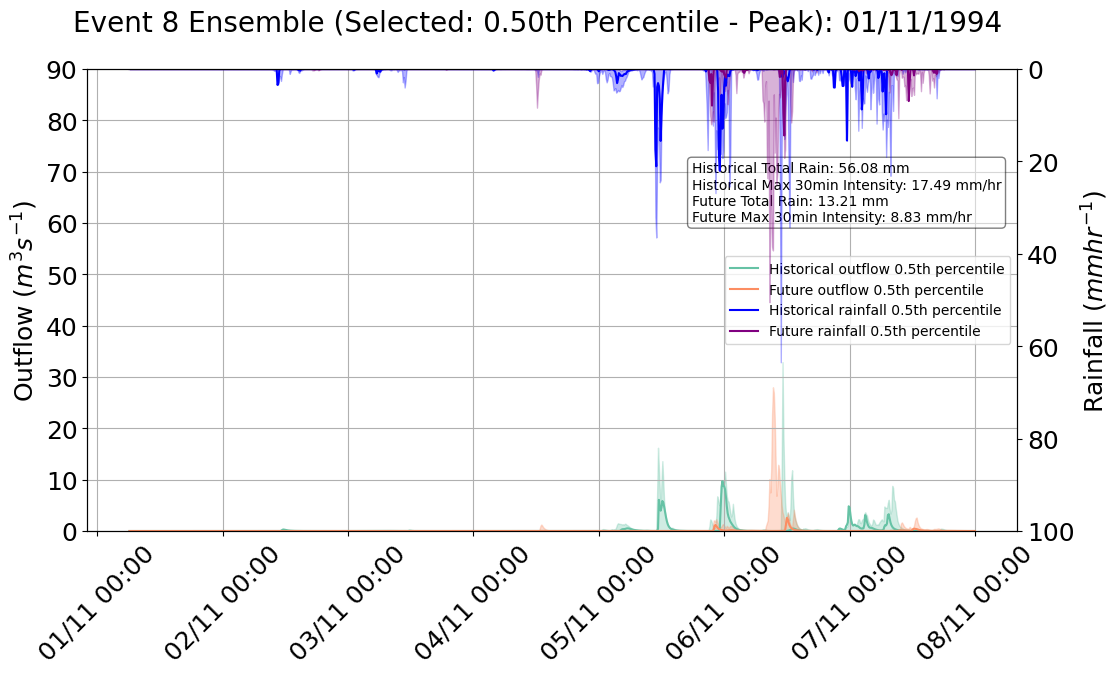

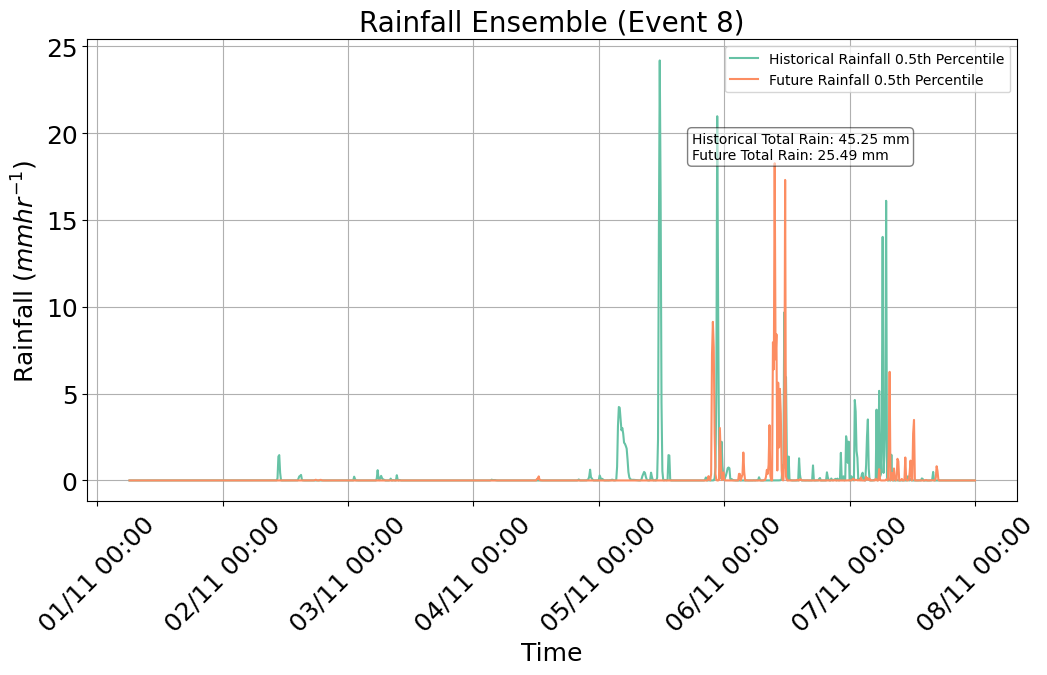

Event number 9, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

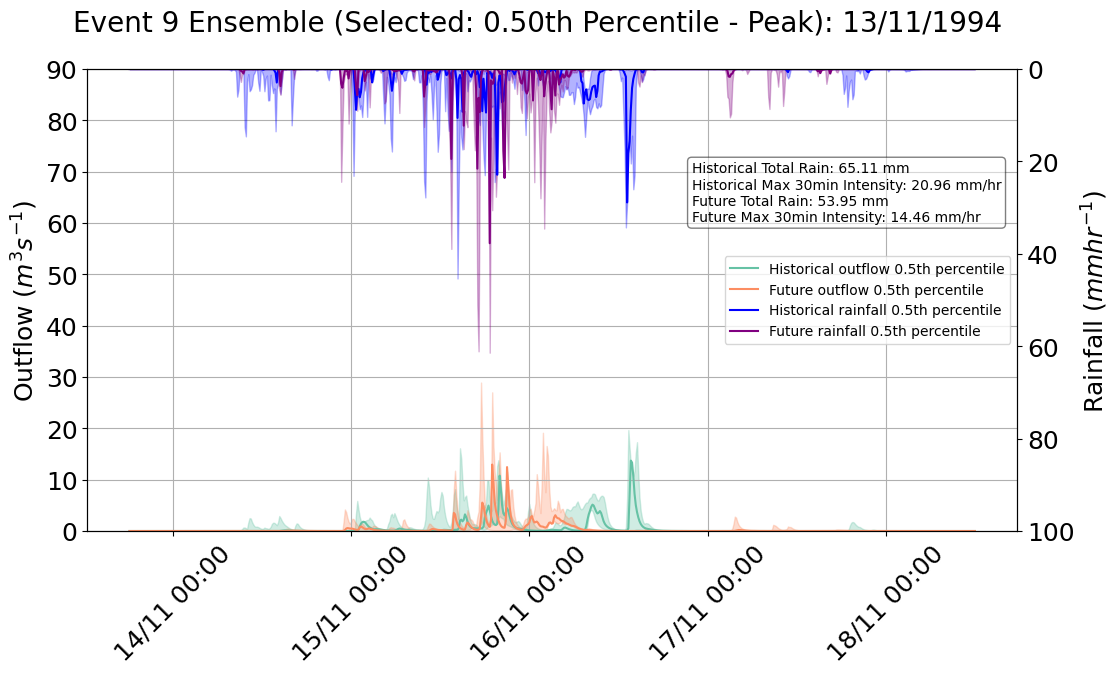

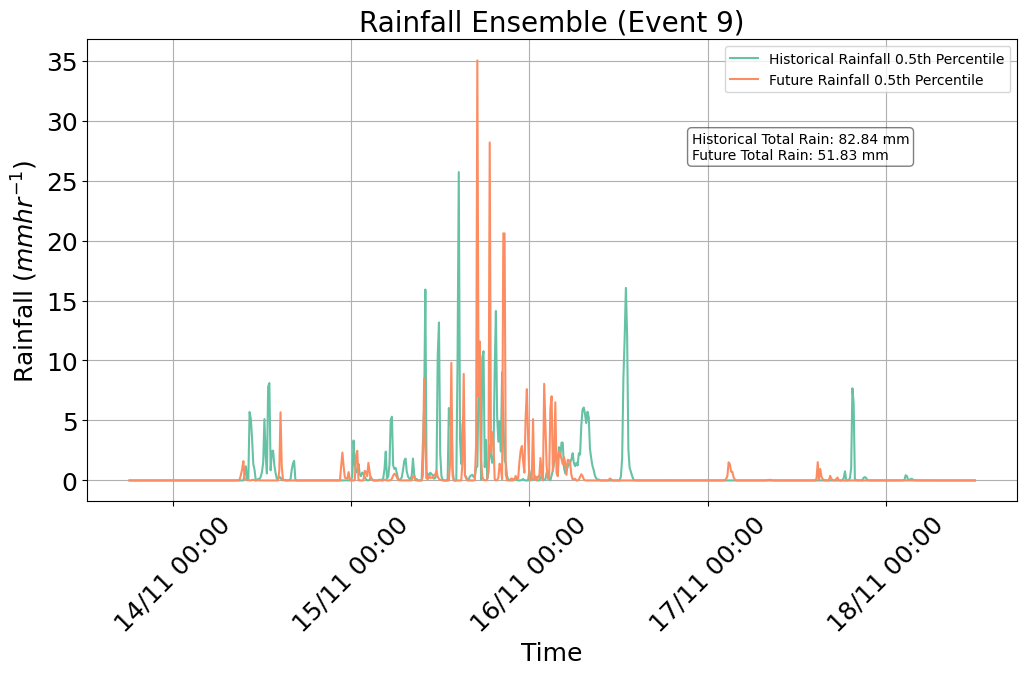

Event number 10, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

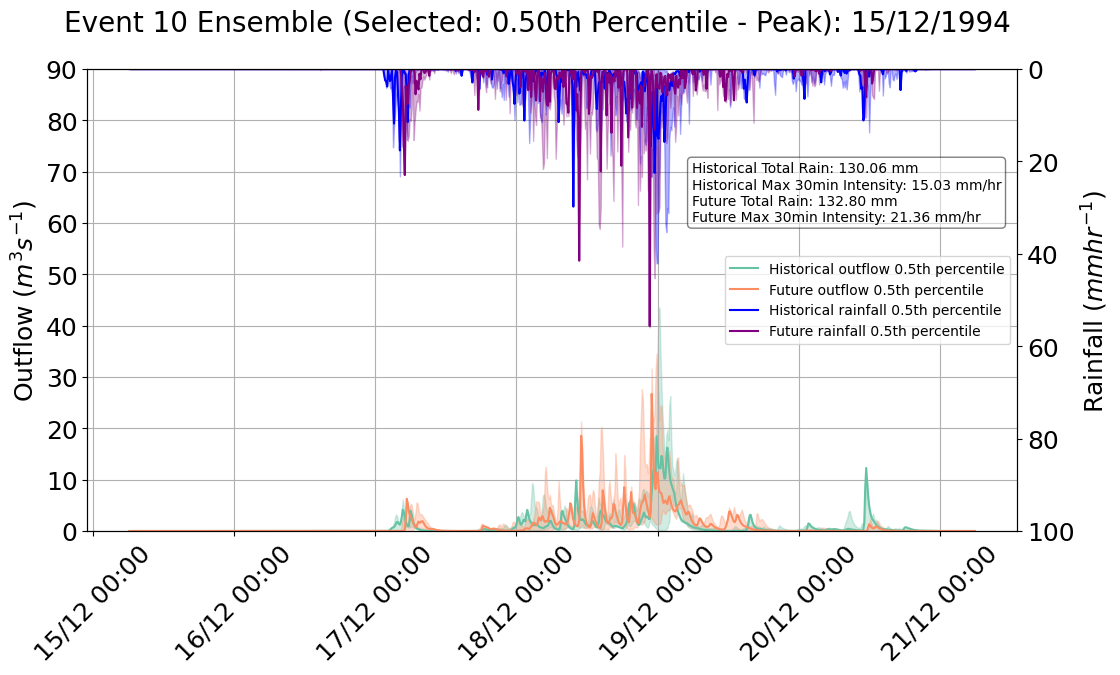

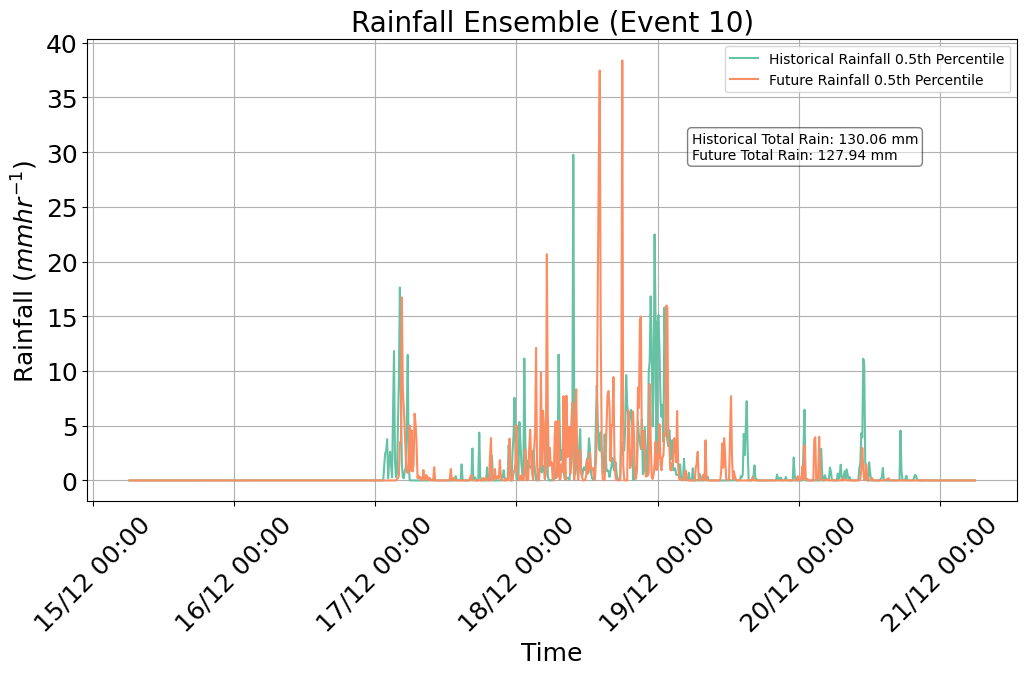

Event number 11, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

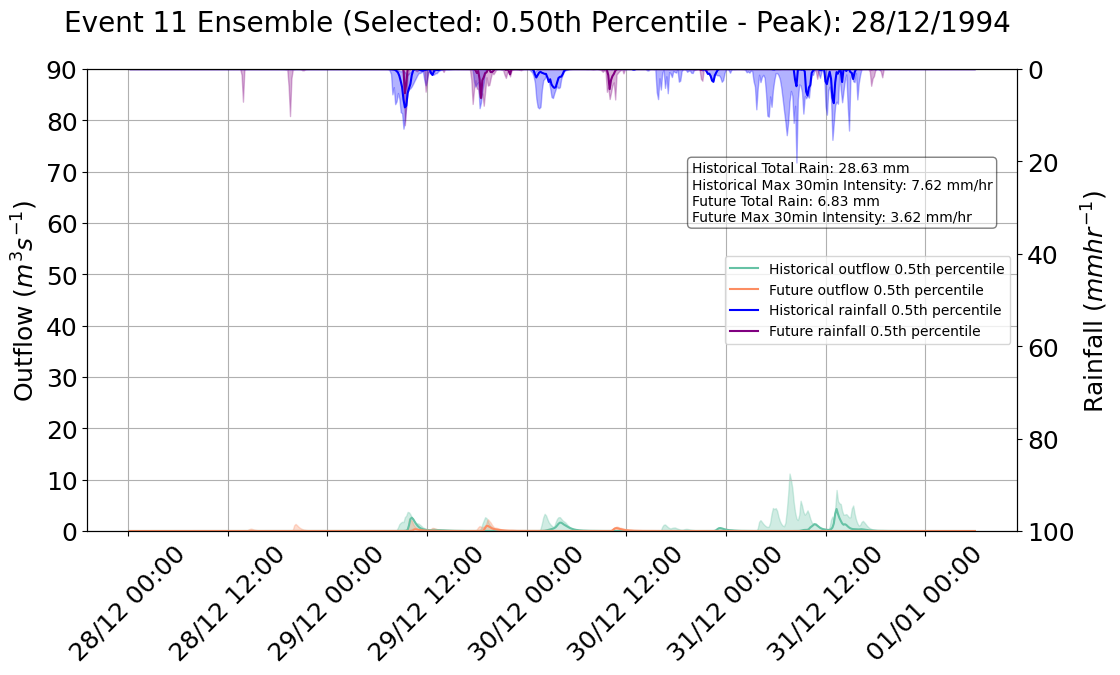

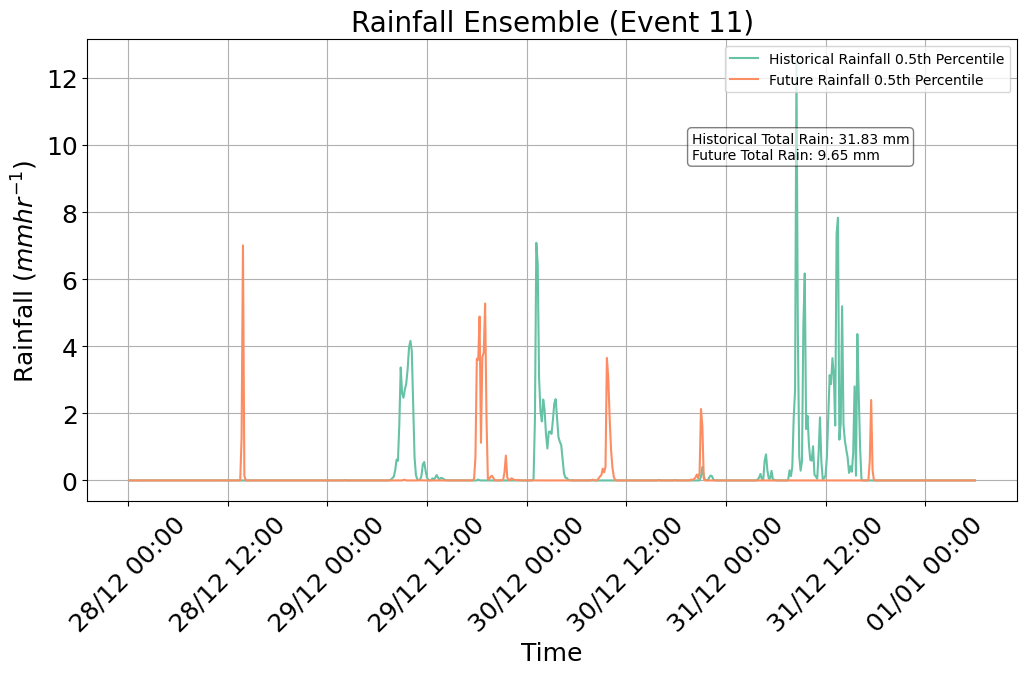

Event number 12, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

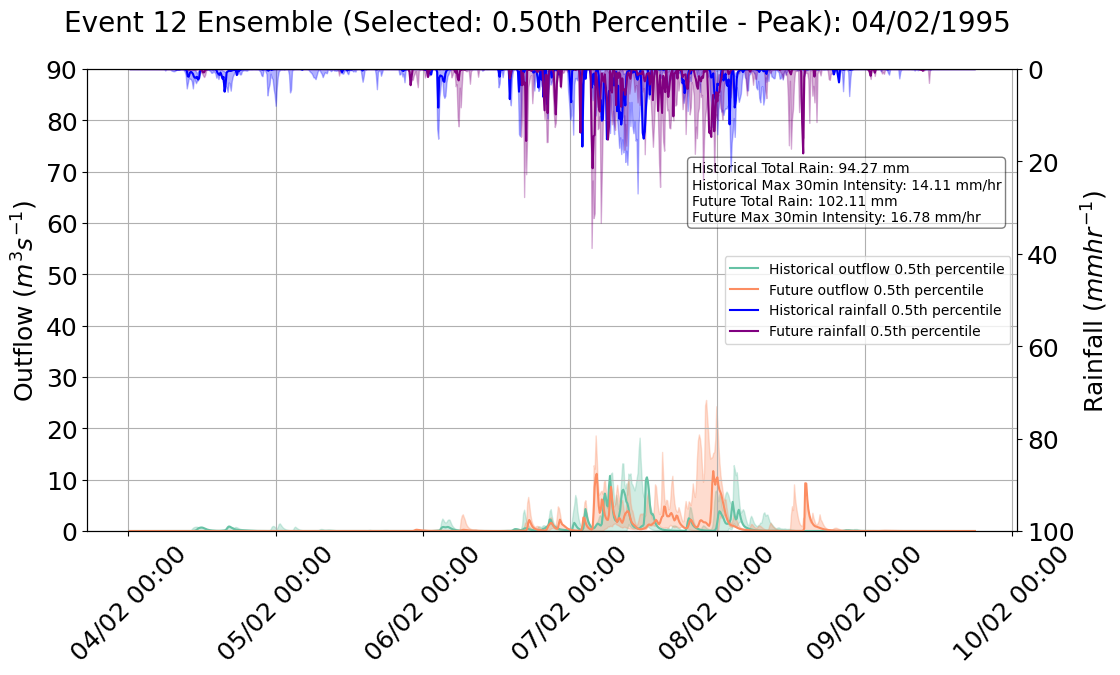

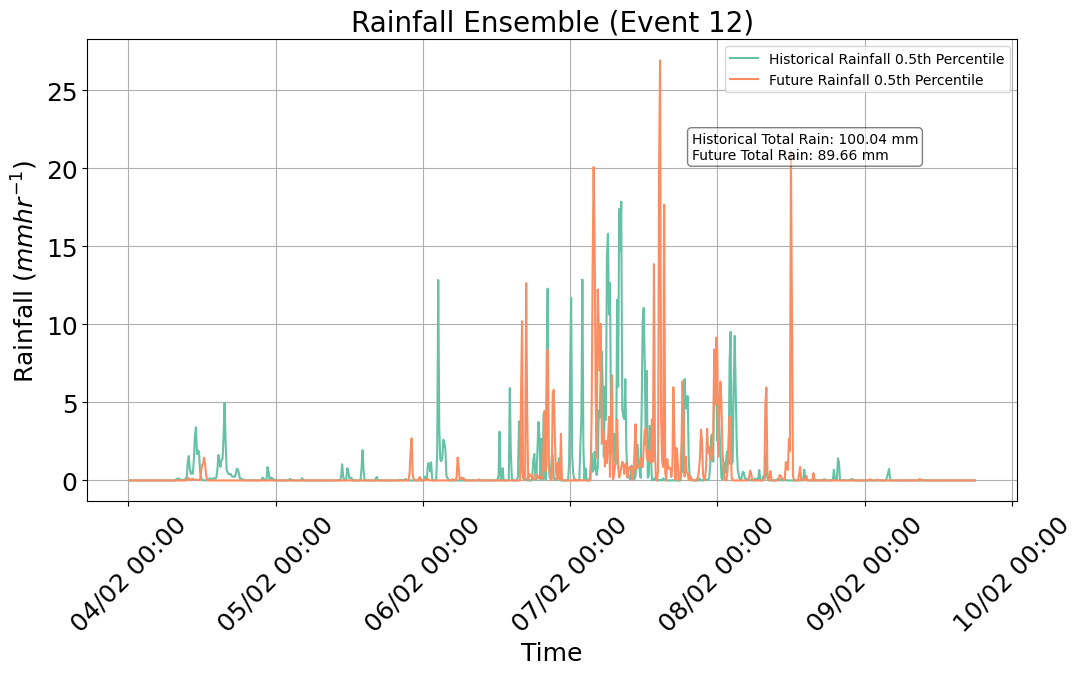

Event number 13, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

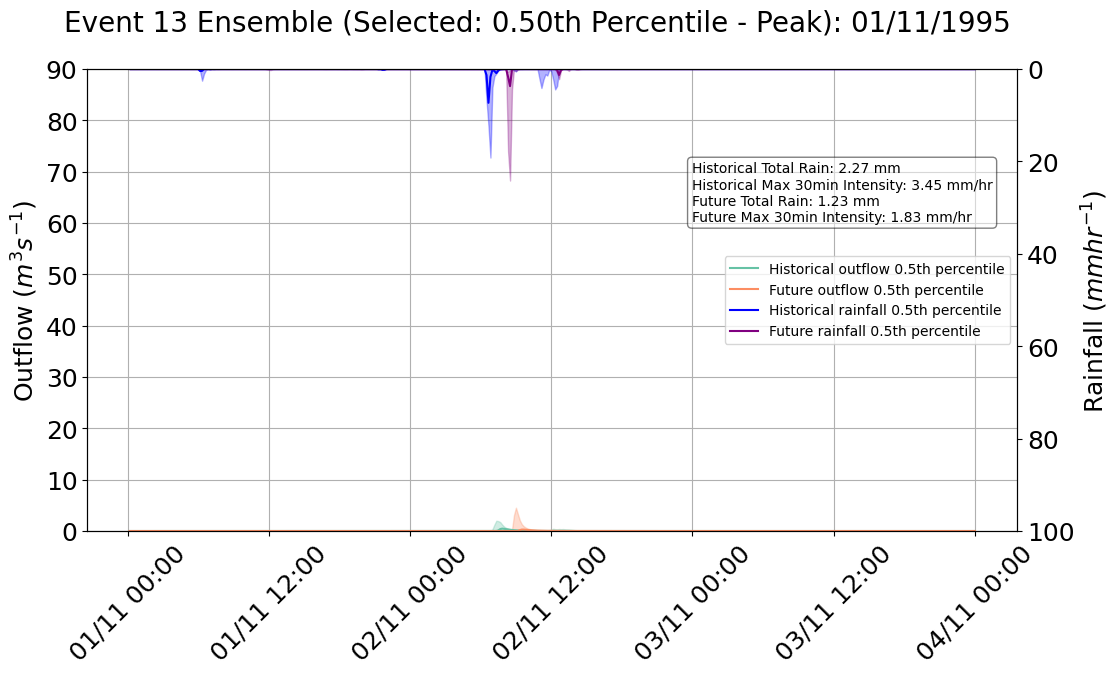

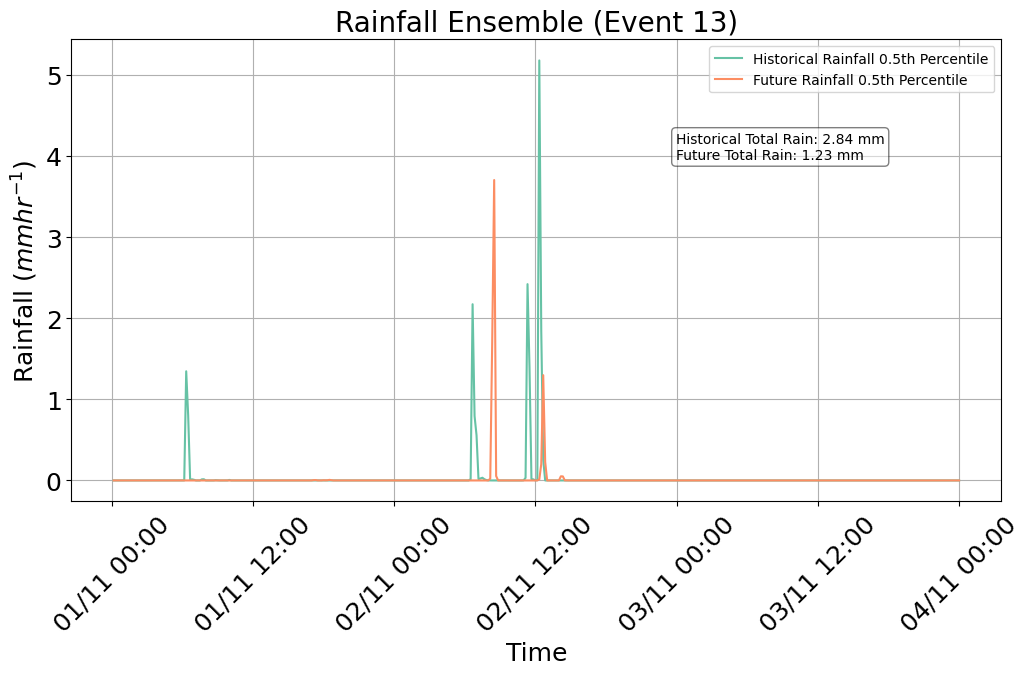

Event number 14, historical class


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/raanana_rain_shift.inp:   0%|          | …

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "C:\Users\raznu\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py", line 3457, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\raznu\AppData\Local\Temp\ipykernel_23944\3565344421.py", line 26, in <module>
    inp.write_file(os.path.join(sim_dir, rain_shift_sim_file_name + '.inp'))
  File "C:\Users\raznu\Anaconda3\lib\site-packages\swmm_api\input_file\inp.py", line 297, in write_file
    with open(filename, 'w', encoding=encoding) as f:
  File "C:\Users\raznu\Anaconda3\lib\codecs.py", line 186, in __init__
    def __init__(self, errors='strict'):
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\raznu\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py", line 2077, in showtraceback
    stb = value._render_traceback_()
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

Duri

TypeError: object of type 'NoneType' has no len()

In [10]:
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change/"
EVENTS_L = [f"{i:02}" for i in range(1, 42)]
wrf_time_type = ['historical', 'future']
raanana_area = 13256.0  # KM
ensemble_member_percentile = 0.5
all_results = []

for event_idx, filename_event in enumerate(EVENTS_L, start=1):
    historical_ensemble = pd.DataFrame()
    future_ensemble = pd.DataFrame()

    for event_type in wrf_time_type:
        print(f'Event number {event_idx}, {event_type} class')
        INP_FILE = r"Final.inp"
        rain_shift_sim_file_name = 'raanana_rain_shift'
        inp = read_inp_file(os.path.join(sim_dir, INP_FILE))

        rainshift_txtfiles_path = fr'\\vscifs.cc.huji.ac.il\hydrolab1\hydrolab\home\Raz\WRF\txtfiles\{event_type}\event_{filename_event}'
        results = []

        for x_shift in np.arange(0, 1, 500):
            for y_shift in np.arange(-20000, 20000, 1000):
                d = np.sqrt(x_shift**2 + y_shift**2)
                rain_shift_txt = read_rain_shift_txt_file(rainshift_txtfiles_path, x_shift, y_shift)
                update_TimeSeriesData(inp, rain_shift_txt)
                inp.write_file(os.path.join(sim_dir, rain_shift_sim_file_name + '.inp'))
                swmm5_run(os.path.join(sim_dir, rain_shift_sim_file_name + '.inp'), progress_size=1)
                sim_df = load_sim_to_df(os.path.join(sim_dir, rain_shift_sim_file_name + '.out'))

                sim_df[sim_df < 0] = 0
                sim_df = sim_df.fillna(0)

                runoff_column = f'ensemble_x{x_shift}_y{y_shift}_runoff'
                rainfall_column = f'ensemble_x{x_shift}_y{y_shift}_rainfall'
                
                if event_type == 'historical':
                    historical_ensemble[runoff_column] = sim_df['SWMM outflow [CMS]']
                    historical_ensemble[rainfall_column] = sim_df['rainfall [mm/hr]']
                elif event_type == 'future':
                    future_ensemble[runoff_column] = sim_df['SWMM outflow [CMS]']
                    future_ensemble[rainfall_column] = sim_df['rainfall [mm/hr]']

                (swmm_total_outflow, swmm_max_outflow, swmm_max_outflow_time,
                 max_10min_intensity, max_20min_intensity, max_30min_intensity, max_60min_intensity,
                 max_120min_intensity, max_240min_intensity, max_360min_intensity,
                 max_720min_intensity, max_1440min_intensity, total_rain,
                 max_10min_intensity_before_peak, max_20min_intensity_before_peak, max_30min_intensity_before_peak, 
                 max_60min_intensity_before_peak, max_120min_intensity_before_peak, max_240min_intensity_before_peak,
                 max_360min_intensity_before_peak, max_720min_intensity_before_peak, max_1440min_intensity_before_peak,
                 total_rain_before_peak) = simulation_stat(sim_df)

                results.append({
                    'event_num': event_idx,
                    'x': x_shift,
                    'y': y_shift,
                    'd': d,
                    f'{event_type} total discharge': swmm_total_outflow,
                    f'{event_type} max discharge': swmm_max_outflow,
                    f'{event_type} runoff_coefficient': (swmm_total_outflow / raanana_area) / total_rain,
                    f'{event_type} max_10min_intensity': max_10min_intensity,
                    f'{event_type} max_20min_intensity': max_20min_intensity,
                    f'{event_type} max_30min_intensity': max_30min_intensity,
                    f'{event_type} max_60min_intensity': max_60min_intensity,
                    f'{event_type} max_120min_intensity': max_120min_intensity,
                    f'{event_type} max_240min_intensity': max_240min_intensity,
                    f'{event_type} max_360min_intensity': max_360min_intensity,
                    f'{event_type} max_720min_intensity': max_720min_intensity,
                    f'{event_type} max_1440min_intensity': max_1440min_intensity,
                    f'{event_type} total_rain': total_rain,
                    f'{event_type} max_10min_intensity_before_peak': max_10min_intensity_before_peak,
                    f'{event_type} max_20min_intensity_before_peak': max_20min_intensity_before_peak,
                    f'{event_type} max_30min_intensity_before_peak': max_30min_intensity_before_peak,
                    f'{event_type} max_60min_intensity_before_peak': max_60min_intensity_before_peak,
                    f'{event_type} max_120min_intensity_before_peak': max_120min_intensity_before_peak,
                    f'{event_type} max_240min_intensity_before_peak': max_240min_intensity_before_peak,
                    f'{event_type} max_360min_intensity_before_peak': max_360min_intensity_before_peak,
                    f'{event_type} max_720min_intensity_before_peak': max_720min_intensity_before_peak,
                    f'{event_type} max_1440min_intensity_before_peak': max_1440min_intensity_before_peak,
                    f'{event_type} total_rain_before_peak': total_rain_before_peak,
                })

                event_results_df = pd.DataFrame(results)
                event_results_df['event_num'] = f'{event_idx:02}'
                event_results_df.columns = pd.MultiIndex.from_tuples([
                    ('event_num', ''),
                    ('x', ''),
                    ('y', ''),
                    ('d', ''),
                    (event_type, 'total discharge'),
                    (event_type, 'max discharge'),
                    (event_type, 'runoff_coefficient'),
                    (event_type, 'max_10min_intensity'),
                    (event_type, 'max_20min_intensity'),
                    (event_type, 'max_30min_intensity'),
                    (event_type, 'max_60min_intensity'),
                    (event_type, 'max_120min_intensity'),
                    (event_type, 'max_240min_intensity'),
                    (event_type, 'max_360min_intensity'),
                    (event_type, 'max_720min_intensity'),
                    (event_type, 'max_1440min_intensity'),
                    (event_type, 'total_rain'),
                    (event_type, 'max_10min_intensity_before_peak'),
                    (event_type, 'max_20min_intensity_before_peak'),
                    (event_type, 'max_30min_intensity_before_peak'),
                    (event_type, 'max_60min_intensity_before_peak'),
                    (event_type, 'max_120min_intensity_before_peak'),
                    (event_type, 'max_240min_intensity_before_peak'),
                    (event_type, 'max_360min_intensity_before_peak'),
                    (event_type, 'max_720min_intensity_before_peak'),
                    (event_type, 'max_1440min_intensity_before_peak'),
                    (event_type, 'total_rain_before_peak'),
                ])

        all_results.append(event_results_df)
        
    if not historical_ensemble.empty and not future_ensemble.empty:
        historical_event_results_df, future_event_results_df = all_results[0], all_results[1]
        plot_ensemble_hydrograph(historical_event_results_df, future_event_results_df, event_idx, historical_ensemble, future_ensemble, ensemble_member_percentile)
#         plot_rainfall_ensemble(historical_ensemble, future_ensemble, event_num, ensemble_member_percentile)
        plot_ensemble_rainfall(historical_event_results_df, future_event_results_df, event_idx, historical_ensemble, future_ensemble, ensemble_member_percentile)

    all_results = []
    